In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df_benin = pd.read_csv("/content/benin-malanville_clean.csv")
df_sierraleone = pd.read_csv("/content/sierraleone-bumbuna_clean.csv")
df_togo = pd.read_csv("/content/togo-dapaong_qc_clean.csv")


## Metric Comparison

In [5]:
df_benin["Country"] = "Benin"
df_sierraleone["Country"] = "Sierra Leone"
df_togo["Country"] = "Togo"


In [6]:
df_all = pd.concat([df_benin, df_sierraleone, df_togo], ignore_index=True)

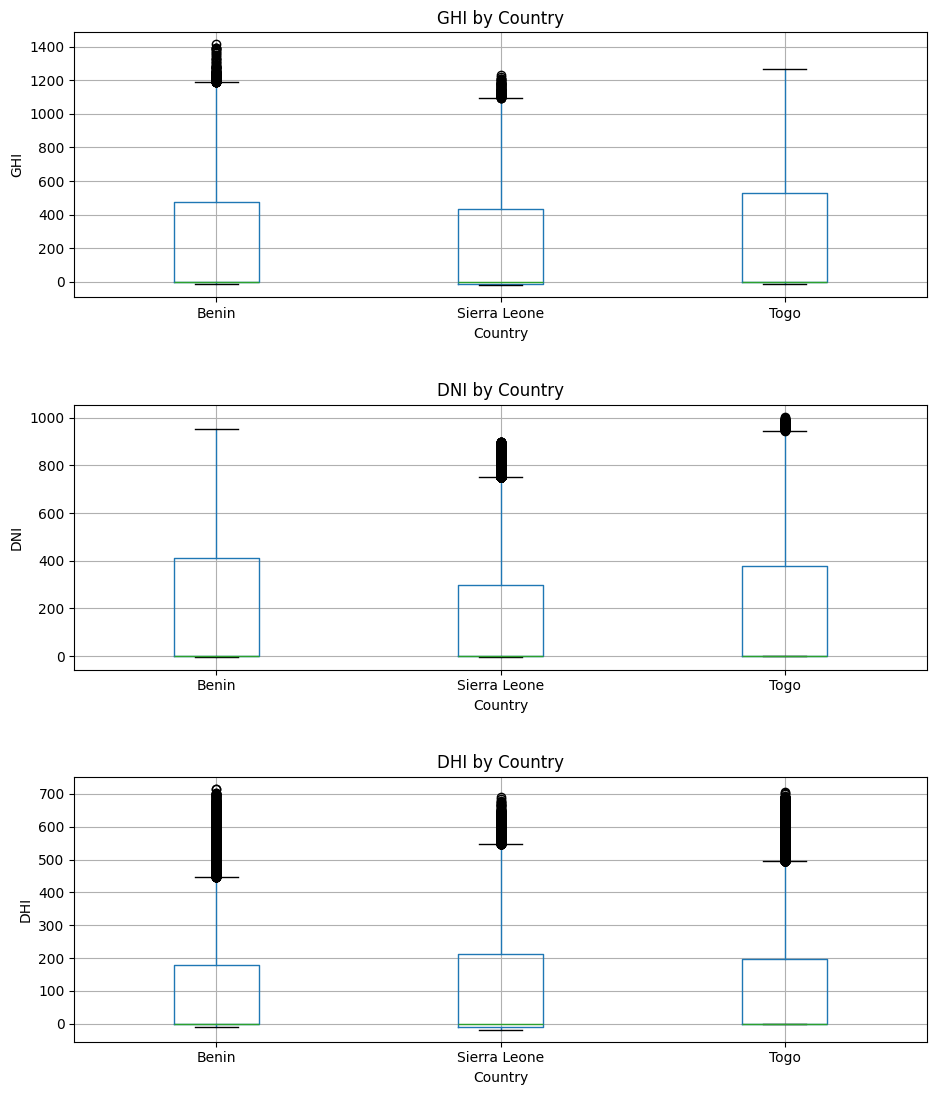

In [13]:
metrics = ['GHI', 'DNI', 'DHI']

fig, axs = plt.subplots(3, 1, figsize=(10, 12))

for i, col in enumerate(metrics):
    df_all.boxplot(column=col, by='Country', ax=axs[i])
    axs[i].set_title(f"{col} by Country")
    axs[i].set_xlabel("Country")
    axs[i].set_ylabel(col)

plt.suptitle("")
plt.tight_layout(pad=3)
plt.show()


In [10]:
summary = df_all.groupby("Country")[["GHI", "DNI", "DHI"]].agg(['mean', 'median', 'std']).round(2)
print(summary)


                 GHI                    DNI                    DHI         \
                mean median     std    mean median     std    mean median   
Country                                                                     
Benin         234.47   -0.5  326.57  194.05   -0.1  291.04   96.91   -0.5   
Sierra Leone  215.65   -0.8  308.98  152.34   -0.1  234.32  102.85   -0.9   
Togo          245.77   -1.0  333.44  189.91    0.0  276.66  111.18    0.8   

                      
                 std  
Country               
Benin         136.88  
Sierra Leone  143.67  
Togo          151.68  


## Statistical Testing